# Task 5: Exploratory Data Analysis (EDA)

In this section, we analyze the seven engineered features created in Task 4:

- Red
- Green
- Blue
- Brightness
- Saturation
- NIR
- NDVI

The goal is to understand the distribution of these features, examine relationships between them, and explore how they differ between cloud-like and other pixels.

The cloud-like label used in this analysis is a proxy based on brightness and saturation.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "Red",
    "Green",
    "Blue",
    "Brightness",
    "Saturation",
    "NIR",
    "NDVI"
]

feature_dir = "/content/drive/MyDrive/engineered_features"

feature_files = sorted(
    glob.glob(os.path.join(feature_dir, "engineered_features_*.npy"))
)

print(f"Found {len(feature_files)} feature files.")

for file in feature_files:
    print(os.path.basename(file))

Found 9 feature files.
engineered_features_031313232113.npy
engineered_features_031313232131.npy
engineered_features_031313232133.npy
engineered_features_031313233002.npy
engineered_features_031313233003.npy
engineered_features_031313233020.npy
engineered_features_031313233021.npy
engineered_features_031313233022.npy
engineered_features_031313233023.npy


Part 1: Load Engineered Features:

Each saved `.npy` file represents one satellite tile. Each pixel in a tile contains seven feature values. For EDA, the feature values from the tiles are converted into rows so they can be analyzed together.

In [ ]:
all_pixels = []

for file in feature_files:
    features = np.load(file)

    print(
        os.path.basename(file),
        "original shape:",
        features.shape
    )

    pixels = features.reshape(-1, 7)

    all_pixels.append(pixels)

all_pixels = np.vstack(all_pixels)

print("\nCombined shape:", all_pixels.shape)

engineered_features_031313232113.npy original shape: (145, 1157, 7)
engineered_features_031313232131.npy original shape: (1740, 1186, 7)
engineered_features_031313232133.npy original shape: (1604, 1212, 7)
engineered_features_031313233002.npy original shape: (127, 1740, 7)
engineered_features_031313233003.npy original shape: (98, 588, 7)
engineered_features_031313233020.npy original shape: (1740, 1740, 7)
engineered_features_031313233021.npy original shape: (1736, 588, 7)
engineered_features_031313233022.npy original shape: (1632, 1740, 7)
engineered_features_031313233023.npy original shape: (1640, 561, 7)

Combined shape: (12262145, 7)


In [ ]:
import rasterio
from rasterio.enums import Resampling

scene_dir = "/content/drive/MyDrive/HurricaneHeleneOct24Data/1030010105AA2600"

valid_pixels_all_tiles = []

for file in feature_files:

    # load tile's 7 engineered features
    features = np.load(file)

    # get the tile ID from the filename
    tile = os.path.basename(file).replace(
        "engineered_features_", ""
    ).replace(".npy", "")

    visual_path = os.path.join(
        scene_dir,
        tile,
        "1030010105AA2600-visual.tif"
    )

    # read the original RGB image at the same 10% resolution
    with rasterio.open(visual_path) as src:

        h = int(src.height * 0.1)
        w = int(src.width * 0.1)

        rgb = src.read(
            [1, 2, 3],
            out_shape=(3, h, w),
            resampling=Resampling.bilinear
        )

    # TRUE = valid pixel
    # FALSE = NoData
    valid = np.any(rgb > 0, axis=0)

    # Find the same cropped region used in Task 4
    rows, cols = np.where(valid)

    valid = valid[
        rows.min():rows.max() + 1,
        cols.min():cols.max() + 1
    ]

    # Keep only valid pixels
    valid_features = features[valid]

    valid_pixels_all_tiles.append(valid_features)

    print(
        tile,
        "| Valid:", valid.sum(),
        "| NoData:", (~valid).sum()
    )

# Combine valid pixels from all 9 tiles
all_valid_pixels = np.vstack(valid_pixels_all_tiles)

print("\nTotal valid pixels:", len(all_valid_pixels))

031313232113 | Valid: 156072 | NoData: 11693
031313232131 | Valid: 2036539 | NoData: 27101
031313232133 | Valid: 1908950 | NoData: 35098
031313233002 | Valid: 194356 | NoData: 26624
031313233003 | Valid: 54834 | NoData: 2790
031313233020 | Valid: 3026631 | NoData: 969
031313233021 | Valid: 993909 | NoData: 26859
031313233022 | Valid: 2813457 | NoData: 26223
031313233023 | Valid: 895091 | NoData: 24949

Total valid pixels: 12079839


Part 2: Organize Pixel Features

The pixel feature values are organized into a Pandas DataFrame. Each row represents one pixel and each column represents one of the seven engineered features.

In [ ]:
df = pd.DataFrame(
    all_valid_pixels,
    columns=feature_names
)

print("DataFrame shape:", df.shape)

df.head()

DataFrame shape: (12079839, 7)


,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000
1,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000
2,0.046154,0.03125,0.031088,0.046154,0.326425,0.0,-1.000000
3,0.071795,0.06250,0.062176,0.071795,0.133975,0.0,-1.000000
4,0.010256,0.00000,0.000000,0.010256,1.000000,0.0,-0.999999


Part 3: Summary Statistics

Summary statistics are calculated for each engineered feature to understand its center, spread, and range across the satellite pixels.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Red,12079839.0,0.374225,0.205217,0.0,0.258373,0.336000,0.468085,1.0
Green,12079839.0,0.373624,0.216471,0.0,0.240196,0.315789,0.512821,1.0
Blue,12079839.0,0.339733,0.227273,0.0,0.196970,0.267123,0.459460,1.0
Brightness,12079839.0,0.407505,0.222247,0.0,0.267943,0.344000,0.557047,1.0
Saturation,12079839.0,0.260029,0.173781,0.0,0.164352,0.241923,0.315844,1.0
NIR,12079839.0,0.145926,0.246642,0.0,0.006797,0.030589,0.145450,1.0
NDVI,12079839.0,-0.597084,0.501168,-1.0,-0.960597,-0.820967,-0.381326,1.0


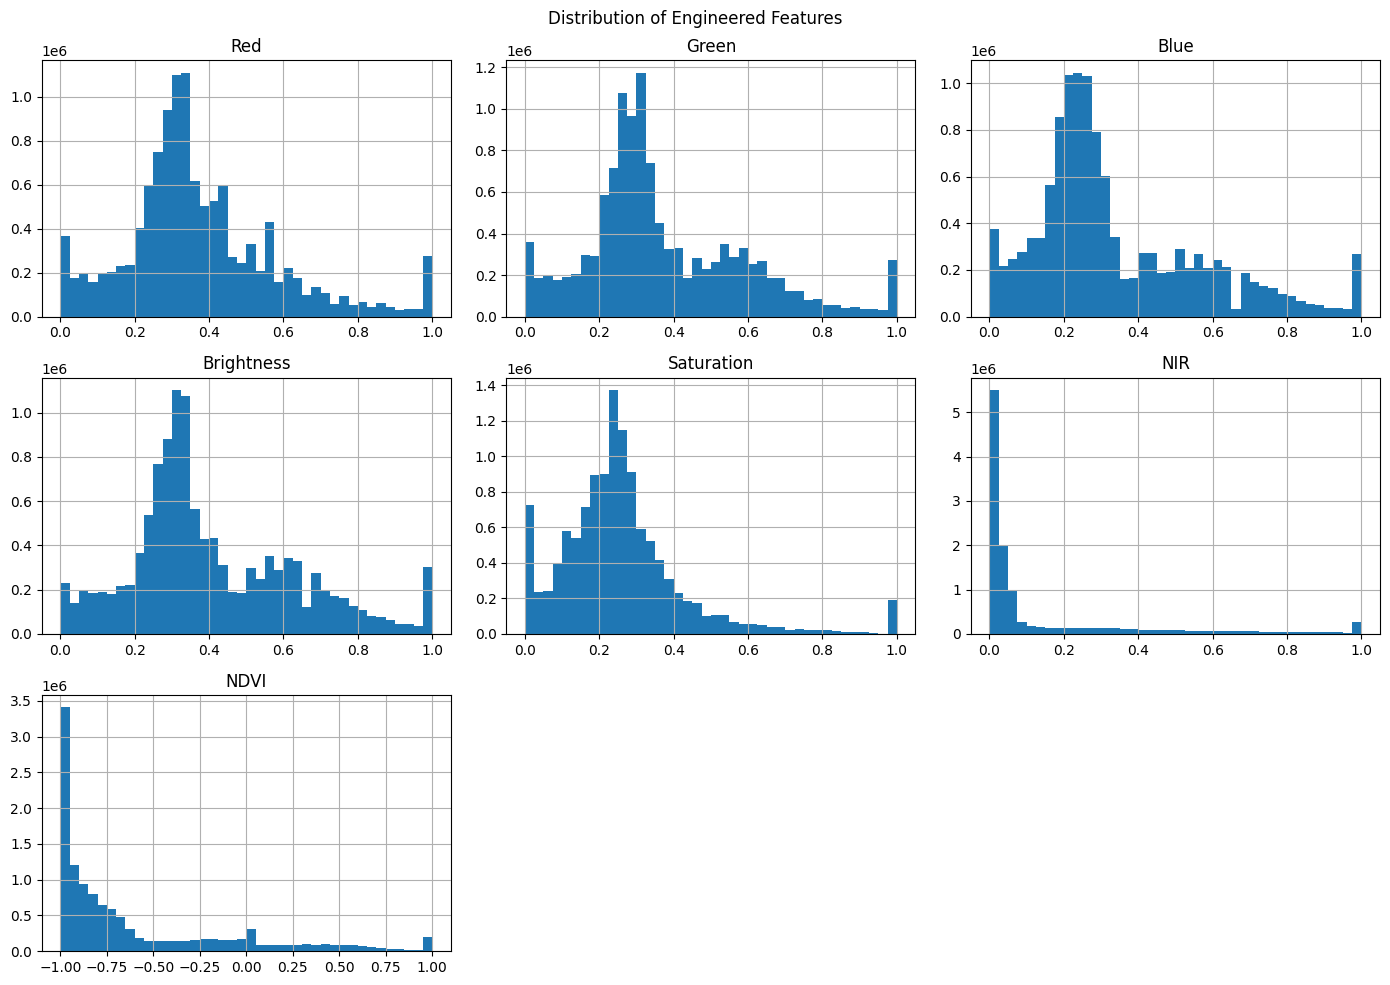

In [ ]:
df[feature_names].hist(
    bins=40,
    figsize=(14, 10)
)

plt.suptitle("Distribution of Engineered Features")
plt.tight_layout()
plt.show()

Part 4: Feature Correlations

A correlation matrix is used to examine how strongly the engineered features are related to one another. Values closer to 1 show that two features tend to increase together, while values closer to -1 show that one tends to decrease as the other increases. Values closer to 0 indicate a weaker relationship.

In [ ]:
corr = df[feature_names].corr(method="spearman")

corr.round(2)

,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
Red,1.00,0.92,0.93,0.96,-0.38,0.11,-0.15
Green,0.92,1.00,0.95,0.97,-0.37,-0.02,-0.27
Blue,0.93,0.95,1.00,0.96,-0.47,0.02,-0.23
Brightness,0.96,0.97,0.96,1.00,-0.30,0.03,-0.22
Saturation,-0.38,-0.37,-0.47,-0.30,1.00,-0.16,-0.08
NIR,0.11,-0.02,0.02,0.03,-0.16,1.00,0.93
NDVI,-0.15,-0.27,-0.23,-0.22,-0.08,0.93,1.00


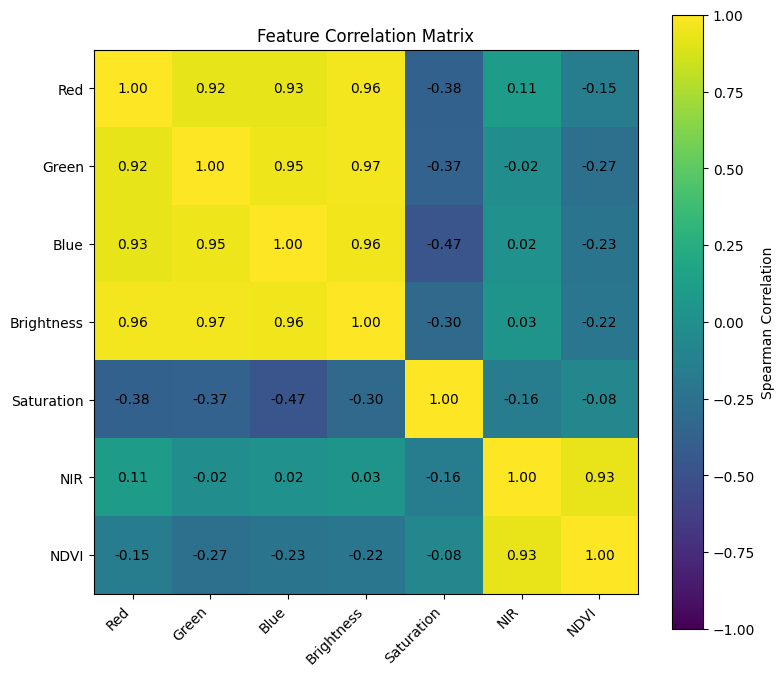

In [ ]:
plt.figure(figsize=(8, 7))

plt.imshow(
    corr,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_names)),
    feature_names
)

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

Part 5: Cloud-Like Pixel Exploration

 Pixels with brightness greater than 0.70 and saturation less than 0.20 are labeled as cloud-like. These labels are only a heuristic.

In [ ]:
df["cloud_proxy"] = (
    (df["Brightness"] > 0.70) &
    (df["Saturation"] < 0.20)
)

df["cloud_proxy"].value_counts()

,count
cloud_proxy,
False,11150064
True,929775


In [ ]:
cloud_percent = (
    df["cloud_proxy"].value_counts(normalize=True) * 100
)

print("\nPercentages:")
print(cloud_percent)


Percentages:
cloud_proxy
False    92.303085
True      7.696915
Name: proportion, dtype: float64


In [ ]:
group_means = df.groupby("cloud_proxy")[feature_names].mean()

group_means

,Red,Green,Blue,Brightness,Saturation,NIR,NDVI
cloud_proxy,,,,,,,
False,0.335598,0.334615,0.297576,0.368982,0.276152,0.115670,-0.615441
True,0.837450,0.841431,0.845284,0.869484,0.066683,0.508768,-0.376940


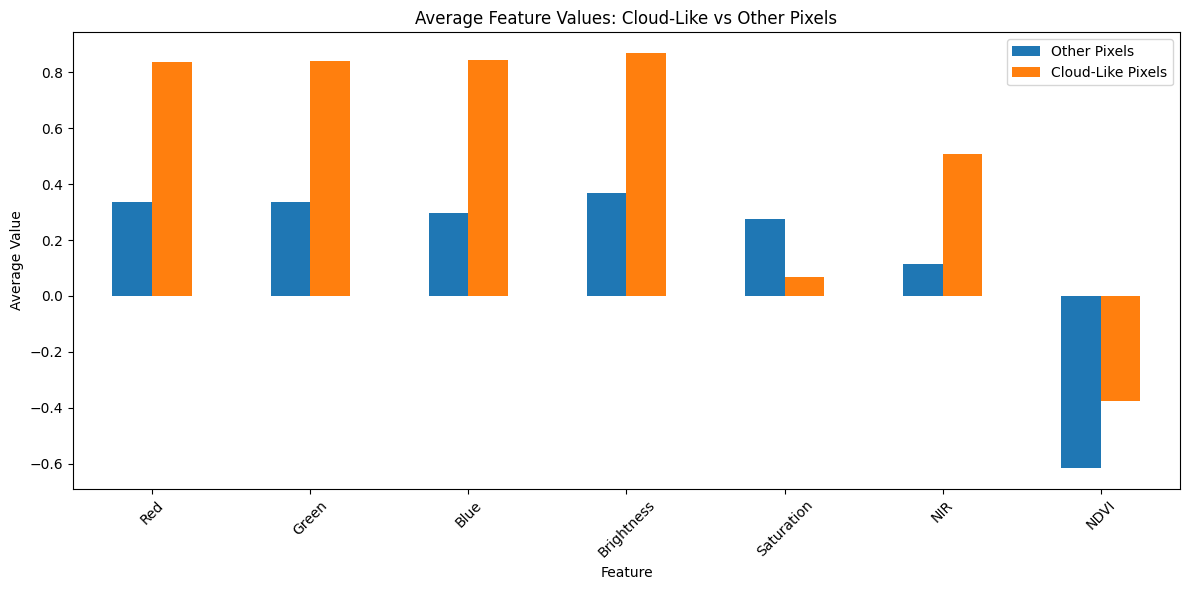

In [ ]:
group_means.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Feature Values: Cloud-Like vs Other Pixels")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(["Other Pixels", "Cloud-Like Pixels"])
plt.tight_layout()
plt.show()

Part 6: Key Findings and Limitations

The exploratory data analysis showed several clear patterns across the seven engineered features. Red, Green, Blue, and Brightness were strongly correlated with each other, indicating that these features contain similar information. Since they are very similar, in a future model they could be dropped or combined. NIR and the NDVI-style feature were also strongly correlated. These correlations show relationships between the features, but they do not by themselves show which features are best at detecting clouds.

With existing heuristic of Brightness > 0.70 and Saturation < 0.20, approximately 7.70% of the valid pixels were classified as cloud-like, while approximately 92.30% were classified as other pixels. Cloud-like pixels had higher average Red, Green, Blue, Brightness, and NIR values and lower average Saturation values than the other pixels.  

Limatation:

The biggest limitation of this analysis is that the cloud-like labels are heuristic labels rather than verified cloud labels. A bright surface with low saturation could satisfy the rule even if it is not a cloud, while a thin or darker cloud might not satisfy the thresholds. It's also possible that snow, ice, or sand may be mislabled as clouds. Also, pixels labeled as “other” are simply pixels that did not meet both thresholds and this does not guarantee that they are cloud-free.